In [45]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [46]:
import glob
import pandas as pd

conditions = [
    "free_recall_baseline",
    "1A",
    "1B",
    "1C",
    "serial_baseline",
    "2C",
    "2D",
    "2E",
]

dfs = {}
for cond in conditions:
    files = sorted(glob.glob(f"Result/{cond}_*.csv"))
    if not files:
        print(f"Ingen filer fundet for {cond}")
        dfs[cond] = pd.DataFrame()
        continue
    participants = [f.split(f"{cond}_")[-1].replace(".csv", "") for f in files]
    print(f"{cond}: {len(files)} deltagere -> {participants}")
    df_cond = pd.concat([pd.read_csv(f) for f in files], ignore_index=True)

    # Normalisér: serial recall-filer bruger 'serial_recall_score' i stedet for
    # 'serial_position_score' -- omdøb så alle betingelser har samme kolonnenavn
    if "serial_recall_score" in df_cond.columns and "serial_position_score" not in df_cond.columns:
        df_cond = df_cond.rename(columns={"serial_recall_score": "serial_position_score"})

    dfs[cond] = df_cond

df_base = dfs["free_recall_baseline"]
df_1A   = dfs["1A"]
df_1B   = dfs["1B"]
df_1C   = dfs["1C"]
df_ser  = dfs["serial_baseline"]
df_2C   = dfs["2C"]
df_2D   = dfs["2D"]
df_2E   = dfs["2E"]

free_recall_baseline: 3 deltagere -> ['Gustav', 'Katinka', 'Selma']
1A: 3 deltagere -> ['Gustav', 'Katinka', 'Selma']
1B: 3 deltagere -> ['Gustav', 'Katinka', 'Selma']
1C: 3 deltagere -> ['Gustav', 'Katinka', 'Selma']
serial_baseline: 3 deltagere -> ['Gustav', 'Katinka', 'Selma']
2C: 3 deltagere -> ['Gustav', 'Katinka', 'Selma']
2D: 3 deltagere -> ['Gustav', 'Katinka', 'Selma']
2E: 3 deltagere -> ['Gustav', 'Katinka', 'Selma']


In [47]:
def smooth_graph(graph_list):
    return [(graph_list[0] + graph_list[1])/2]+[(graph_list[i] + graph_list[i-1] + graph_list[i+1])/3 for i in range(1,len(graph_list)-1)] + [(graph_list[-2] + graph_list[-1])/2]

In [48]:
def prepare_trial_data(*dfs, trial_names=None, smooth=False):
    """
    Convert trial DataFrames into long format for Seaborn.

    Each DataFrame must contain a 'serial_position_score' column
    containing strings such as "0 1 0 0 1".
    """

    if trial_names is None:
        trial_names = [f"trial_{i+1}" for i in range(len(dfs))]

    if len(trial_names) != len(dfs):
        raise ValueError(
            "The number of trial names must match the number of DataFrames."
        )

    rows = []

    for df, trial_name in zip(dfs, trial_names):

        if "serial_position_score" not in df.columns:
            raise ValueError(
                f"DataFrame for '{trial_name}' must contain "
                "'serial_position_score'."
            )

        for scores in df["serial_position_score"]:

            # Convert "0 1 0 0 1" -> [0, 1, 0, 0, 1]
            scores = [int(x) for x in scores.split()]
            if smooth:
                scores = smooth_graph(scores)
            for x, y in enumerate(scores):
                rows.append({
                    "x": x,
                    "y": y,
                    "trial": trial_name
                })

    return pd.DataFrame(rows)

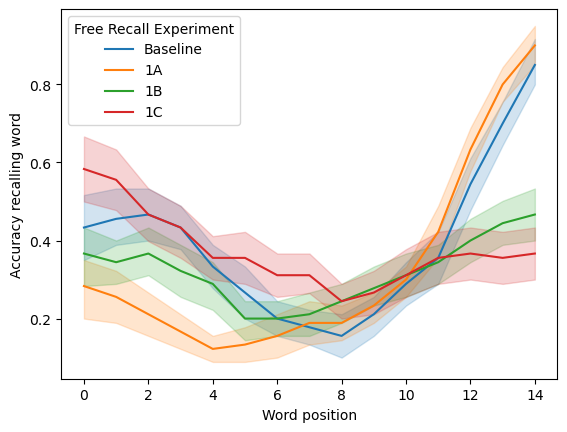

In [49]:
#Baseline 1.
df_plotdata = prepare_trial_data(df_base,df_1A,df_1B,df_1C, trial_names=["Baseline","1A", "1B","1C"], smooth=True)

sns.lineplot(
    data=df_plotdata,
    x="x",
    y="y",
    hue="trial",       # separate curve for each event
    errorbar=("ci",70),     # confidence interval
    n_boot=1000
)

plt.xlabel("Word position")
plt.ylabel("Accuracy recalling word")
plt.legend(title="Free Recall Experiment")
plt.show()

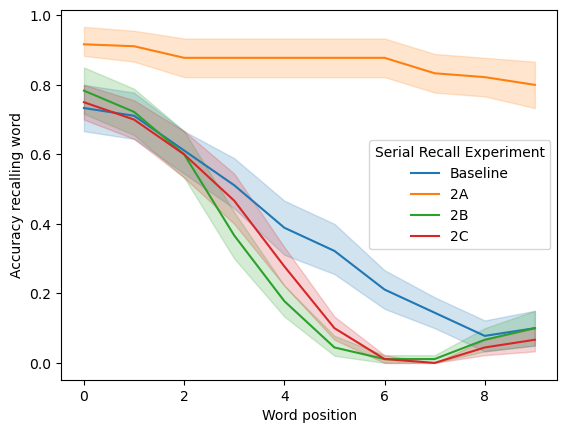

In [50]:
#Serial 2.
df_plotdata = prepare_trial_data(df_ser,df_2C,df_2D,df_2E, trial_names=["Baseline","2A", "2B","2C"], smooth=True)

sns.lineplot(
    data=df_plotdata,
    x="x",
    y="y",
    hue="trial",       # separate curve for each event
    errorbar=("ci",70),     # confidence interval
    n_boot=1000
)

plt.xlabel("Word position")
plt.ylabel("Accuracy recalling word")
plt.legend(title="Serial Recall Experiment")
plt.show()